# 03 — 閾值化與形態學處理

本 notebook 聚焦在兩個傳統影像處理中很核心的操作：

1. **Thresholding（閾值化）**：將灰階影像轉換成二值遮罩。
2. **Morphology（形態學處理）**：清理、連接、分離或修正二值區域。

關鍵在於：thresholding 通常只能得到一個初步 mask，但這個 mask 可能會有雜訊、破洞或斷裂。  
因此 morphology 常常會接在 thresholding 後面，用來讓 mask 更適合後續量測、檢測或判斷。

## 1. 為什麼 thresholding 很重要

Thresholding 是將前景與背景分開的最簡單方法之一。

在許多工業視覺或 AOI 任務中，目標不一定是理解整張影像的語意。  
更多時候是回答具體問題：

- 亮色表面上是否有黑點瑕疵？
- 某個區域是否比預期更大？
- 區域是連通還是斷裂？
- 二值 mask 裡是否出現不該存在的小顆粒？

這個方法本質上就是一個 **pixel-level decision rule**：

> 如果 pixel intensity 符合條件，就標記為前景；否則標記為背景。

它的優點是簡單、快速；缺點是容易受到光照、對比、陰影與雜訊影響。

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 建立輸出資料夾
output_dir = "outputs/03_thresholding_and_morphology"
os.makedirs(output_dir, exist_ok=True)

print("OpenCV version:", cv2.__version__)
print("Output directory:", output_dir)

OpenCV version: 4.13.0
Output directory: outputs/03_thresholding_and_morphology


## 2. 建立一張合成的檢測影像

為了讓這份 notebook 可以直接執行，這裡不依賴外部圖片，而是直接產生一張合成影像。

這張影像模擬一個簡單的檢測情境：

- 一個偏亮的產品表面
- 不均勻光照
- 類似黑點瑕疵的區域
- 隨機小雜訊點

這樣做的好處是每個處理步驟的影響都能清楚觀察。

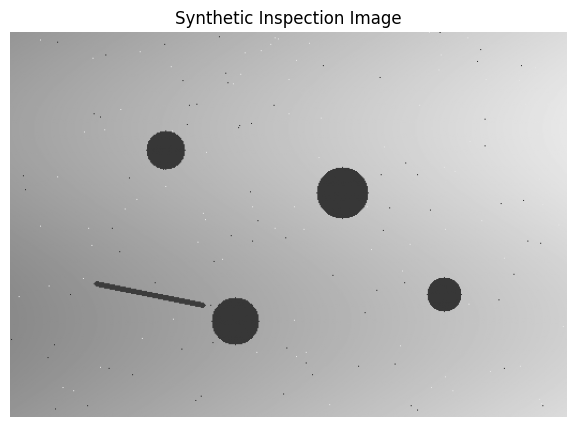

True

In [2]:
def create_synthetic_inspection_image(height=360, width=520, seed=7):
    np.random.seed(seed)

    # 建立偏亮的背景表面
    image = np.full((height, width), 185, dtype=np.float32)

    # 加入由左到右的不均勻光照
    x_gradient = np.linspace(-35, 35, width, dtype=np.float32)
    image += x_gradient[None, :]

    # 加入輕微的垂直方向光照變化
    y_gradient = 12 * np.sin(np.linspace(0, 2 * np.pi, height, dtype=np.float32))
    image += y_gradient[:, None]

    # 加入暗色瑕疵區域
    defects = [
        (145, 110, 18),
        (310, 150, 24),
        (405, 245, 16),
        (210, 270, 22),
    ]

    for cx, cy, radius in defects:
        cv2.circle(image, (cx, cy), radius, 55, -1)

    # 加入一道類似刮痕的細長瑕疵
    cv2.line(image, (80, 235), (180, 255), 60, 4)

    # 加入隨機雜訊點
    for _ in range(160):
        x = np.random.randint(0, width)
        y = np.random.randint(0, height)
        value = np.random.choice([45, 230])
        image[y, x] = value

    image = np.clip(image, 0, 255).astype(np.uint8)
    return image

gray = create_synthetic_inspection_image()

plt.figure(figsize=(8, 5))
plt.imshow(gray, cmap="gray", vmin=0, vmax=255)
plt.title("Synthetic Inspection Image")
plt.axis("off")
plt.show()

cv2.imwrite(os.path.join(output_dir, "01_synthetic_inspection_image.png"), gray)

## 3. 觀察灰階值分布

在做 thresholding 之前，先觀察 histogram 是很有幫助的。

Histogram 可以讓我們知道 pixel intensity 的分布狀況。  
如果前景與背景的灰階值明顯分開，global thresholding 通常會比較有效。  
如果兩者重疊嚴重，單一 threshold 就容易失敗。

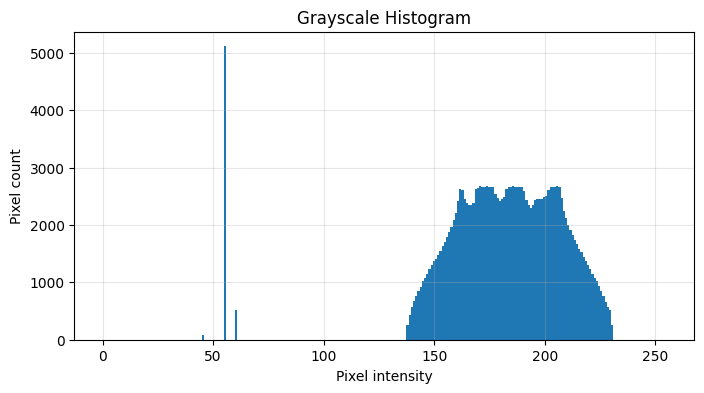

In [3]:
plt.figure(figsize=(8, 4))
plt.hist(gray.ravel(), bins=256, range=(0, 255))
plt.title("Grayscale Histogram")
plt.xlabel("Pixel intensity")
plt.ylabel("Pixel count")
plt.grid(True, alpha=0.3)
plt.show()

hist_path = os.path.join(output_dir, "02_grayscale_histogram.png")
plt.figure(figsize=(8, 4))
plt.hist(gray.ravel(), bins=256, range=(0, 255))
plt.title("Grayscale Histogram")
plt.xlabel("Pixel intensity")
plt.ylabel("Pixel count")
plt.grid(True, alpha=0.3)
plt.savefig(hist_path, dpi=150, bbox_inches="tight")
plt.close()

## 4. Global thresholding

Global thresholding 是對整張影像使用同一個固定 threshold。

在這個暗色瑕疵檢測情境中，我們會將比 threshold 更暗的 pixel 標記為前景。

關鍵細節是：這個方法假設同一個 threshold 可以適用於整張影像。  
但如果影像有光照不均，這個假設通常會變弱。

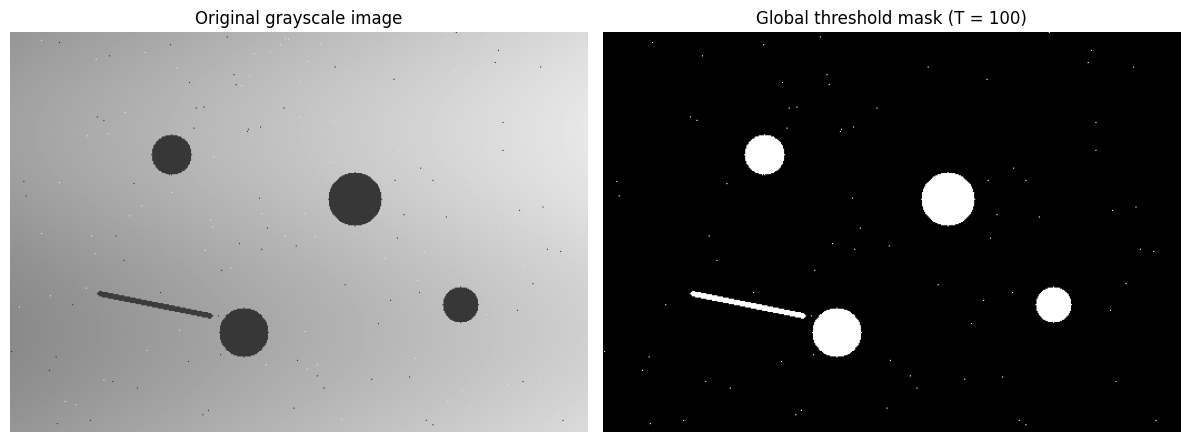

True

In [4]:
threshold_value = 100

# THRESH_BINARY_INV 會讓暗色 pixel 變成白色前景
_, global_mask = cv2.threshold(gray, threshold_value, 255, cv2.THRESH_BINARY_INV)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray", vmin=0, vmax=255)
plt.title("Original grayscale image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(global_mask, cmap="gray", vmin=0, vmax=255)
plt.title(f"Global threshold mask (T = {threshold_value})")
plt.axis("off")

plt.tight_layout()
plt.show()

cv2.imwrite(os.path.join(output_dir, "03_global_threshold_mask.png"), global_mask)

## 5. Threshold 的敏感度

固定 threshold 只要數值不同，結果就可能差很多。

這也是為什麼 thresholding 不應該被視為一個完全機械式的步驟。  
在實務系統中，threshold 通常要根據影像條件、瑕疵對比、誤判與漏判風險來選擇。

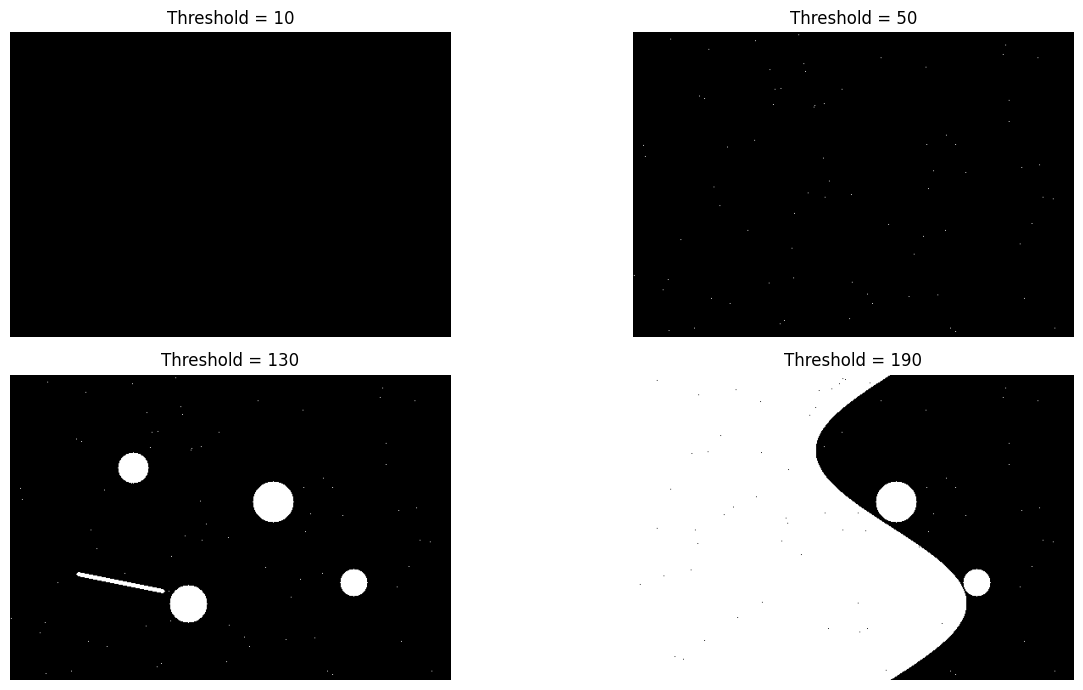

In [17]:
threshold_values = [10, 50, 130, 190]

plt.figure(figsize=(14, 7))

for i, t in enumerate(threshold_values):
    _, mask = cv2.threshold(gray, t, 255, cv2.THRESH_BINARY_INV)

    plt.subplot(2, 2, i + 1)
    plt.imshow(mask, cmap="gray", vmin=0, vmax=255)
    plt.title(f"Threshold = {t}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# 儲存比較圖
save_path = os.path.join(output_dir, "04_threshold_sensitivity_comparison.png")
plt.figure(figsize=(14, 7))
for i, t in enumerate(threshold_values):
    _, mask = cv2.threshold(gray, t, 255, cv2.THRESH_BINARY_INV)
    plt.subplot(2, 2, i + 1)
    plt.imshow(mask, cmap="gray", vmin=0, vmax=255)
    plt.title(f"Threshold = {t}")
    plt.axis("off")
plt.tight_layout()
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.close()

## 6. Otsu's thresholding

Otsu's method 會根據灰階 histogram 自動選擇 threshold。

當前景與背景在 histogram 上形成兩個可分離群組時，Otsu 通常表現不錯。  
但是如果影像存在光照不均、陰影或前景背景對比不足，Otsu 也可能不穩定。

所以 Otsu 很實用，但它不是萬能。它仍然依賴影像本身的灰階分布。

Otsu threshold: 176.0


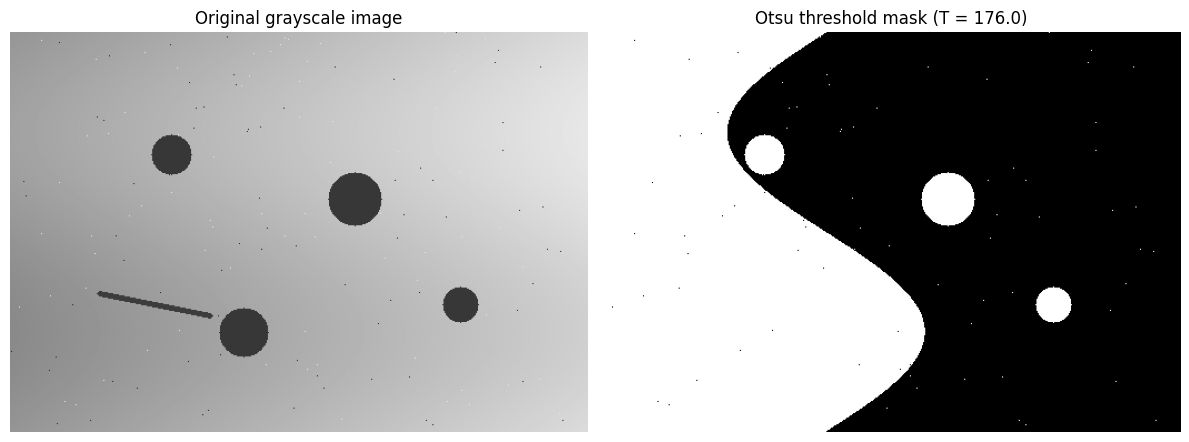

True

In [6]:
otsu_threshold, otsu_mask = cv2.threshold(
    gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

print("Otsu threshold:", otsu_threshold)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray", vmin=0, vmax=255)
plt.title("Original grayscale image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(otsu_mask, cmap="gray", vmin=0, vmax=255)
plt.title(f"Otsu threshold mask (T = {otsu_threshold:.1f})")
plt.axis("off")

plt.tight_layout()
plt.show()

cv2.imwrite(os.path.join(output_dir, "05_otsu_threshold_mask.png"), otsu_mask)

## 7. Adaptive thresholding

Adaptive thresholding 會根據局部區域計算 threshold。

這在光照不均的影像中特別有用。  
它不是要求同一個 threshold 適用整張影像，而是讓每個局部區域使用自己的判斷標準。

代價是：adaptive thresholding 也可能放大局部紋理或雜訊。

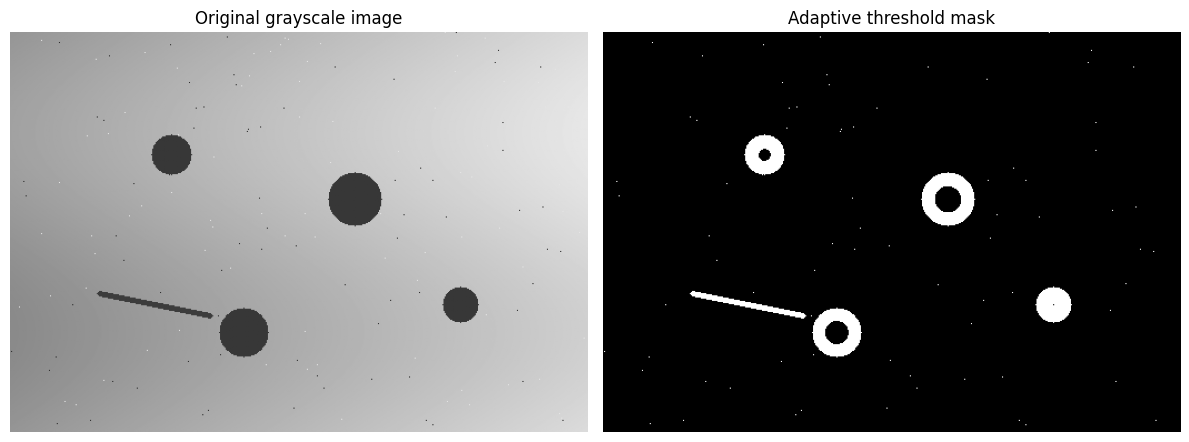

True

In [7]:
adaptive_mask = cv2.adaptiveThreshold(
    gray,
    maxValue=255,
    adaptiveMethod=cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    thresholdType=cv2.THRESH_BINARY_INV,
    blockSize=41,
    C=7
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray", vmin=0, vmax=255)
plt.title("Original grayscale image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(adaptive_mask, cmap="gray", vmin=0, vmax=255)
plt.title("Adaptive threshold mask")
plt.axis("off")

plt.tight_layout()
plt.show()

cv2.imwrite(os.path.join(output_dir, "06_adaptive_threshold_mask.png"), adaptive_mask)

## 8. 比較不同 thresholding 方法

實務上的比較不應該只問哪個 mask 看起來比較乾淨。  
更重要的是問：哪個 mask 比較支援下一步操作。

例如：

- 如果目標是瑕疵計數，小雜訊點就會造成干擾。
- 如果目標是偵測刮痕，細長且連續的結構就應該被保留。
- 如果目標是面積量測，破碎區域可能會造成量測錯誤。

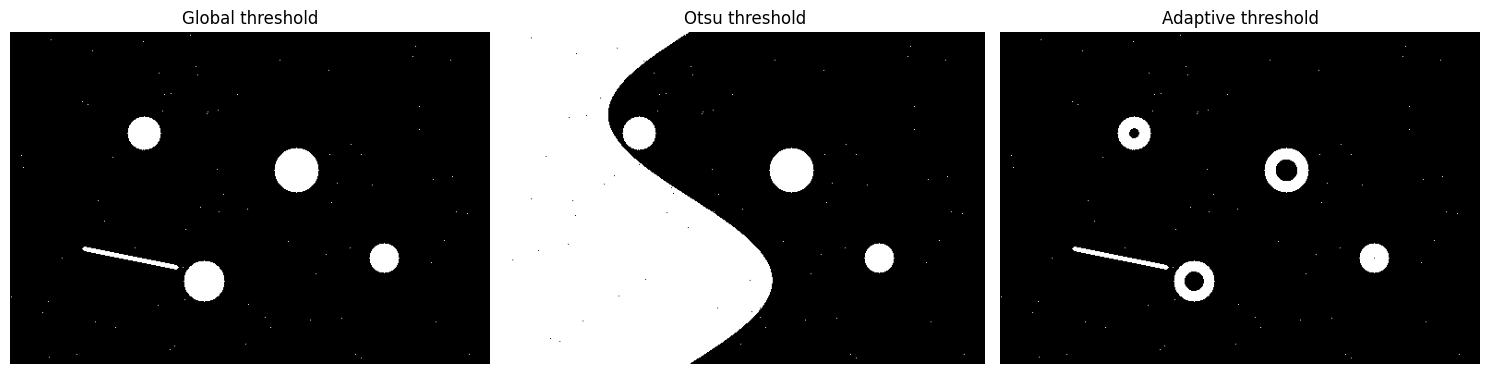

In [8]:
methods = {
    "Global threshold": global_mask,
    "Otsu threshold": otsu_mask,
    "Adaptive threshold": adaptive_mask,
}

plt.figure(figsize=(15, 5))

for i, (title, mask) in enumerate(methods.items()):
    plt.subplot(1, 3, i + 1)
    plt.imshow(mask, cmap="gray", vmin=0, vmax=255)
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

save_path = os.path.join(output_dir, "07_thresholding_methods_comparison.png")
plt.figure(figsize=(15, 5))
for i, (title, mask) in enumerate(methods.items()):
    plt.subplot(1, 3, i + 1)
    plt.imshow(mask, cmap="gray", vmin=0, vmax=255)
    plt.title(title)
    plt.axis("off")
plt.tight_layout()
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.close()

## 9. Morphological operations

Morphology 通常作用在二值影像上，並且使用一個小形狀作為 **structuring element** 或 **kernel**。

常見操作包含：

- **Erosion**：縮小白色前景區域。
- **Dilation**：擴張白色前景區域。
- **Opening**：先 erosion 再 dilation，常用於去除小雜訊。
- **Closing**：先 dilation 再 erosion，常用於填補小孔洞或連接小斷裂。

關鍵細節是：morphology 並不理解物件語意。  
它只是根據局部鄰域規則改變形狀。

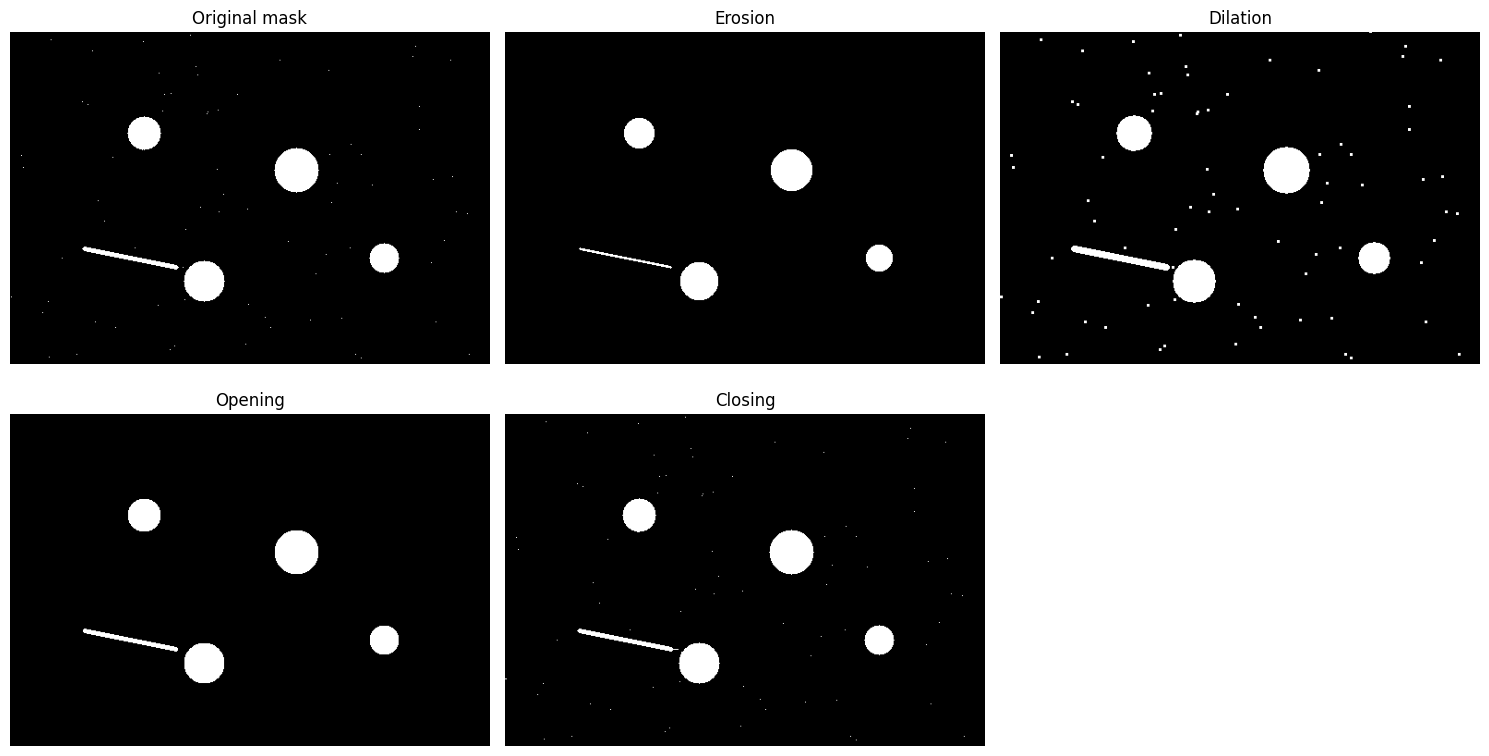

In [9]:
kernel_3x3 = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
kernel_5x5 = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))

eroded = cv2.erode(global_mask, kernel_3x3, iterations=1)
dilated = cv2.dilate(global_mask, kernel_3x3, iterations=1)
opened = cv2.morphologyEx(global_mask, cv2.MORPH_OPEN, kernel_3x3, iterations=1)
closed = cv2.morphologyEx(global_mask, cv2.MORPH_CLOSE, kernel_5x5, iterations=1)

morph_results = {
    "Original mask": global_mask,
    "Erosion": eroded,
    "Dilation": dilated,
    "Opening": opened,
    "Closing": closed,
}

plt.figure(figsize=(15, 8))

for i, (title, img) in enumerate(morph_results.items()):
    plt.subplot(2, 3, i + 1)
    plt.imshow(img, cmap="gray", vmin=0, vmax=255)
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

for title, img in morph_results.items():
    filename = title.lower().replace(" ", "_") + ".png"
    cv2.imwrite(os.path.join(output_dir, f"08_{filename}"), img)

## 10. 使用 opening 去除雜訊

Opening 常常接在 thresholding 後面，因為它可以移除小型孤立前景點。

不過，它也可能移除細小或較弱的真實瑕疵。  
這就是重要 trade-off：清理越強，可能越能降低誤判，但也可能增加漏判。

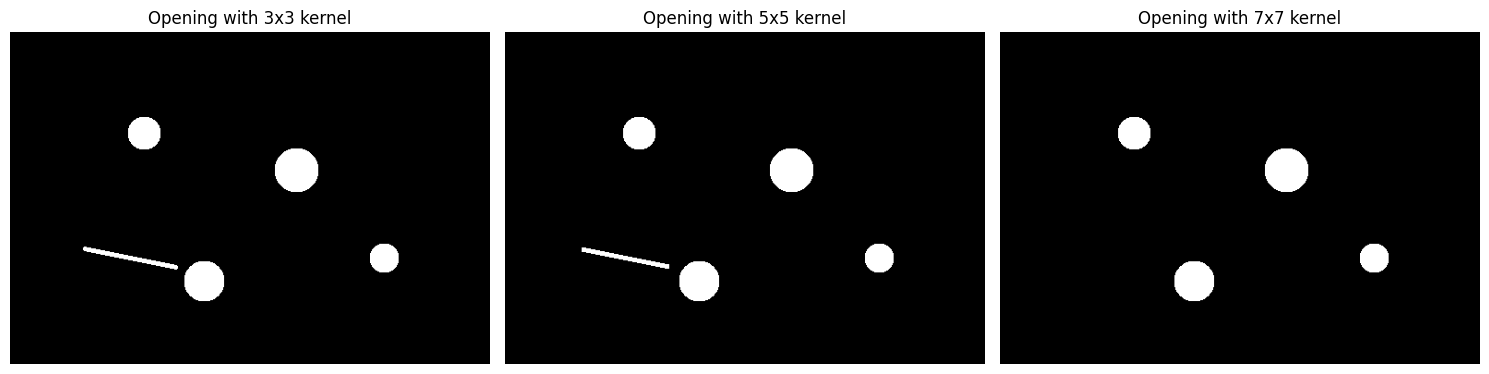

In [10]:
kernels = {
    "3x3": cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3)),
    "5x5": cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5)),
    "7x7": cv2.getStructuringElement(cv2.MORPH_RECT, (7, 7)),
}

plt.figure(figsize=(15, 5))

for i, (name, kernel) in enumerate(kernels.items()):
    opened_mask = cv2.morphologyEx(global_mask, cv2.MORPH_OPEN, kernel, iterations=1)

    plt.subplot(1, 3, i + 1)
    plt.imshow(opened_mask, cmap="gray", vmin=0, vmax=255)
    plt.title(f"Opening with {name} kernel")
    plt.axis("off")

plt.tight_layout()
plt.show()

save_path = os.path.join(output_dir, "09_opening_kernel_size_comparison.png")
plt.figure(figsize=(15, 5))
for i, (name, kernel) in enumerate(kernels.items()):
    opened_mask = cv2.morphologyEx(global_mask, cv2.MORPH_OPEN, kernel, iterations=1)
    plt.subplot(1, 3, i + 1)
    plt.imshow(opened_mask, cmap="gray", vmin=0, vmax=255)
    plt.title(f"Opening with {name} kernel")
    plt.axis("off")
plt.tight_layout()
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.close()

## 11. 使用 closing 填補斷裂與孔洞

Closing 可以連接相近的前景區域，或填補小孔洞。

當 mask 因為雜訊、低對比或光照不均而出現破碎時，closing 會很有幫助。  
但如果 kernel 太大，closing 也可能把原本分離的瑕疵錯誤合併成同一個區域。

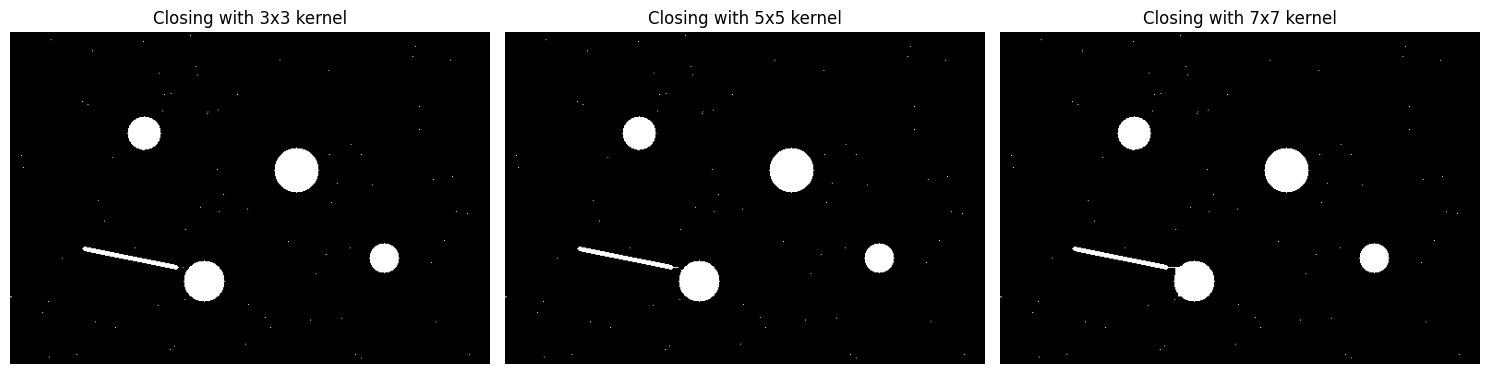

In [11]:
plt.figure(figsize=(15, 5))

for i, (name, kernel) in enumerate(kernels.items()):
    closed_mask = cv2.morphologyEx(global_mask, cv2.MORPH_CLOSE, kernel, iterations=1)

    plt.subplot(1, 3, i + 1)
    plt.imshow(closed_mask, cmap="gray", vmin=0, vmax=255)
    plt.title(f"Closing with {name} kernel")
    plt.axis("off")

plt.tight_layout()
plt.show()

save_path = os.path.join(output_dir, "10_closing_kernel_size_comparison.png")
plt.figure(figsize=(15, 5))
for i, (name, kernel) in enumerate(kernels.items()):
    closed_mask = cv2.morphologyEx(global_mask, cv2.MORPH_CLOSE, kernel, iterations=1)
    plt.subplot(1, 3, i + 1)
    plt.imshow(closed_mask, cmap="gray", vmin=0, vmax=255)
    plt.title(f"Closing with {name} kernel")
    plt.axis("off")
plt.tight_layout()
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.close()

## 12. Connected component analysis

在 thresholding 與 morphology 之後，常見的下一步是區域分析。

Connected component analysis 會為每個連通前景區域分配一個 ID。  
這樣我們就可以量測：

- area
- bounding box
- centroid
- detected region 數量

這一步通常是從影像處理走向檢測決策的橋樑。

In [12]:
# 先使用 opening 減少小雜訊，再進行 connected component analysis
clean_mask = cv2.morphologyEx(global_mask, cv2.MORPH_OPEN, kernel_3x3, iterations=1)

num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(clean_mask, connectivity=8)

component_vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

min_area = 20
detected_components = []

for label_id in range(1, num_labels):  # label 0 是背景
    x, y, w, h, area = stats[label_id]

    if area < min_area:
        continue

    cx, cy = centroids[label_id]
    detected_components.append({
        "label_id": label_id,
        "x": int(x),
        "y": int(y),
        "width": int(w),
        "height": int(h),
        "area": int(area),
        "centroid_x": float(cx),
        "centroid_y": float(cy),
    })

    cv2.rectangle(component_vis, (x, y), (x + w, y + h), (0, 0, 255), 2)
    cv2.circle(component_vis, (int(cx), int(cy)), 3, (255, 0, 0), -1)

print("Number of detected components:", len(detected_components))
detected_components

Number of detected components: 5


[{'label_id': 1,
  'x': 128,
  'y': 93,
  'width': 35,
  'height': 35,
  'area': 1005,
  'centroid_x': 145.0,
  'centroid_y': 110.0},
 {'label_id': 2,
  'x': 287,
  'y': 127,
  'width': 47,
  'height': 47,
  'area': 1789,
  'centroid_x': 310.0,
  'centroid_y': 150.0},
 {'label_id': 3,
  'x': 390,
  'y': 230,
  'width': 31,
  'height': 31,
  'area': 793,
  'centroid_x': 405.0,
  'centroid_y': 245.0},
 {'label_id': 4,
  'x': 79,
  'y': 233,
  'width': 103,
  'height': 25,
  'area': 511,
  'centroid_x': 130.0,
  'centroid_y': 245.0},
 {'label_id': 5,
  'x': 189,
  'y': 249,
  'width': 43,
  'height': 43,
  'area': 1513,
  'centroid_x': 210.0,
  'centroid_y': 270.0}]

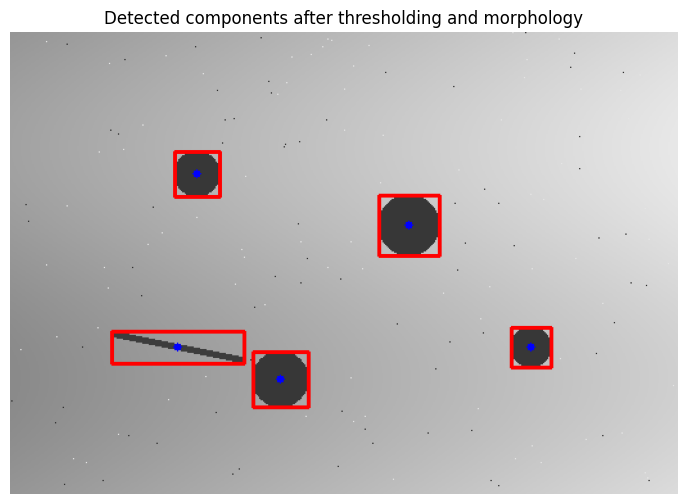

True

In [13]:
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(component_vis, cv2.COLOR_BGR2RGB))
plt.title("Detected components after thresholding and morphology")
plt.axis("off")
plt.show()

cv2.imwrite(
    os.path.join(output_dir, "11_connected_components_detection.png"),
    component_vis
)

## 13. 儲存一張簡潔的檢測流程報告圖

一份適合作品集展示的 notebook 不應該只顯示中間結果。  
它也應該輸出一張能總結整個流程的比較圖。

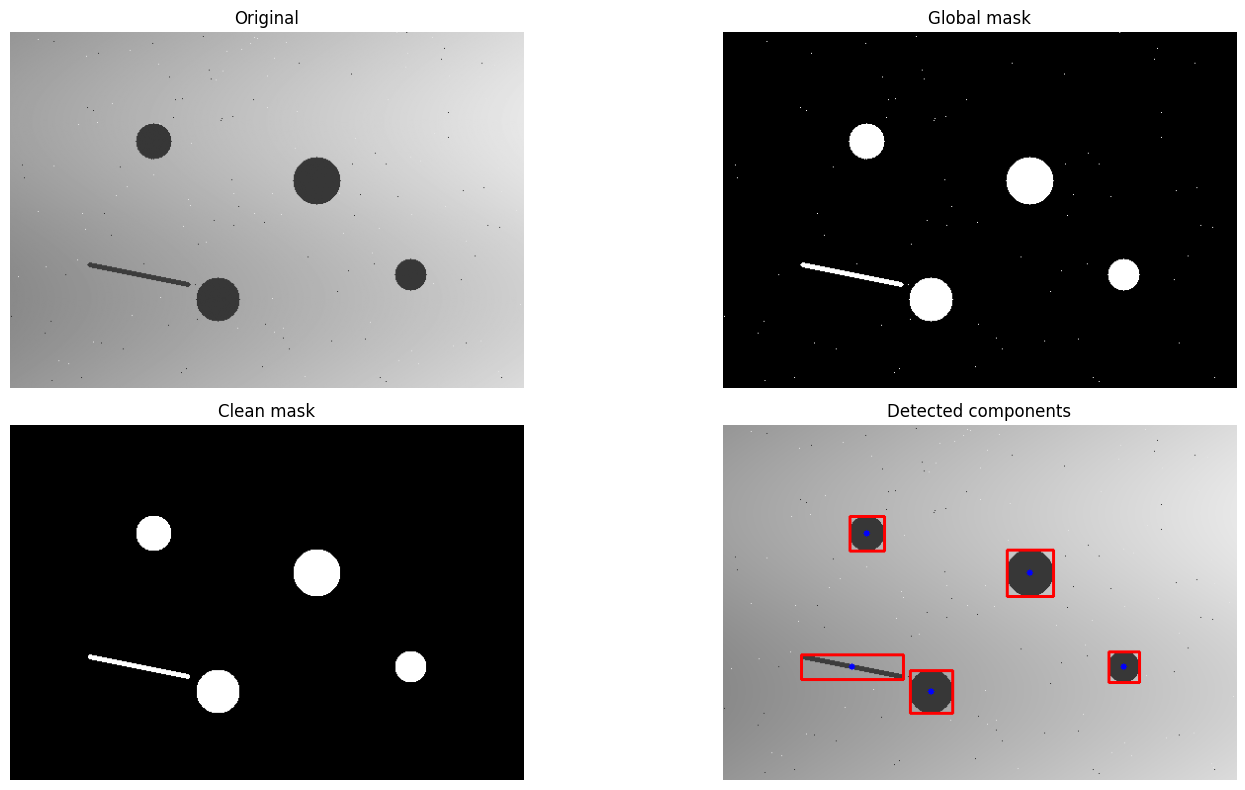

In [14]:
report_items = [
    ("Original", gray),
    ("Global mask", global_mask),
    ("Clean mask", clean_mask),
    ("Detected components", cv2.cvtColor(component_vis, cv2.COLOR_BGR2RGB)),
]

plt.figure(figsize=(16, 8))

for i, (title, img) in enumerate(report_items):
    plt.subplot(2, 2, i + 1)
    if img.ndim == 2:
        plt.imshow(img, cmap="gray", vmin=0, vmax=255)
    else:
        plt.imshow(img)
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.savefig(
    os.path.join(output_dir, "12_pipeline_summary_report.png"),
    dpi=150,
    bbox_inches="tight"
)
plt.show()

## 14. Engineering notes

Thresholding 和 morphology 雖然簡單，但在影像條件受控的情況下非常實用。

實務觀察如下：

1. **Global thresholding 很快，但前提是光照要穩定。**  
   如果影像有明顯光照不均，同一個 threshold 可能在某些區域過度檢出，在某些區域又漏掉瑕疵。

2. **Otsu 可以自動選 threshold，但不代表不用判斷。**  
   它比較適合前景與背景灰階分布能明顯分開的情況。

3. **Adaptive thresholding 對光照不均有幫助，但可能放大局部雜訊。**  
   通常需要搭配 morphology 或 area filtering。

4. **Opening 可以降低小型誤判，但可能刪掉細小真瑕疵。**  
   Kernel size 會直接影響清理強度與細節保留程度。

5. **Closing 可以修補破碎 mask，但也可能錯誤合併不同物件。**  
   它適合處理小斷裂與小孔洞，但在物件分離很重要時要小心使用。

6. **Connected component analysis 會把 binary mask 轉成可量測的區域。**  
   這一步是讓影像處理結果進入檢測決策的重要階段。

一個實務上的理解是：

> Thresholding 產生候選 mask，morphology 修正 mask，component analysis 將 mask 轉成可量測的證據。

## 15. Conclusion

本 notebook 示範了一個基礎但實用的二值分割流程：

1. 建立或讀取灰階影像。
2. 觀察灰階值分布。
3. 使用 global、Otsu 與 adaptive thresholding。
4. 使用 morphology 清理或修補 binary mask。
5. 使用 connected components 擷取可量測區域。
6. 儲存輸出結果，方便檢查與作品集展示。

這套流程特別適合傳統電腦視覺任務，例如 AOI、瑕疵檢測、簡單物件分割與 rule-based inspection。